기본 환경 설정 - 한글 폰트 및 패키지 설치

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,552 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and direc

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] =False

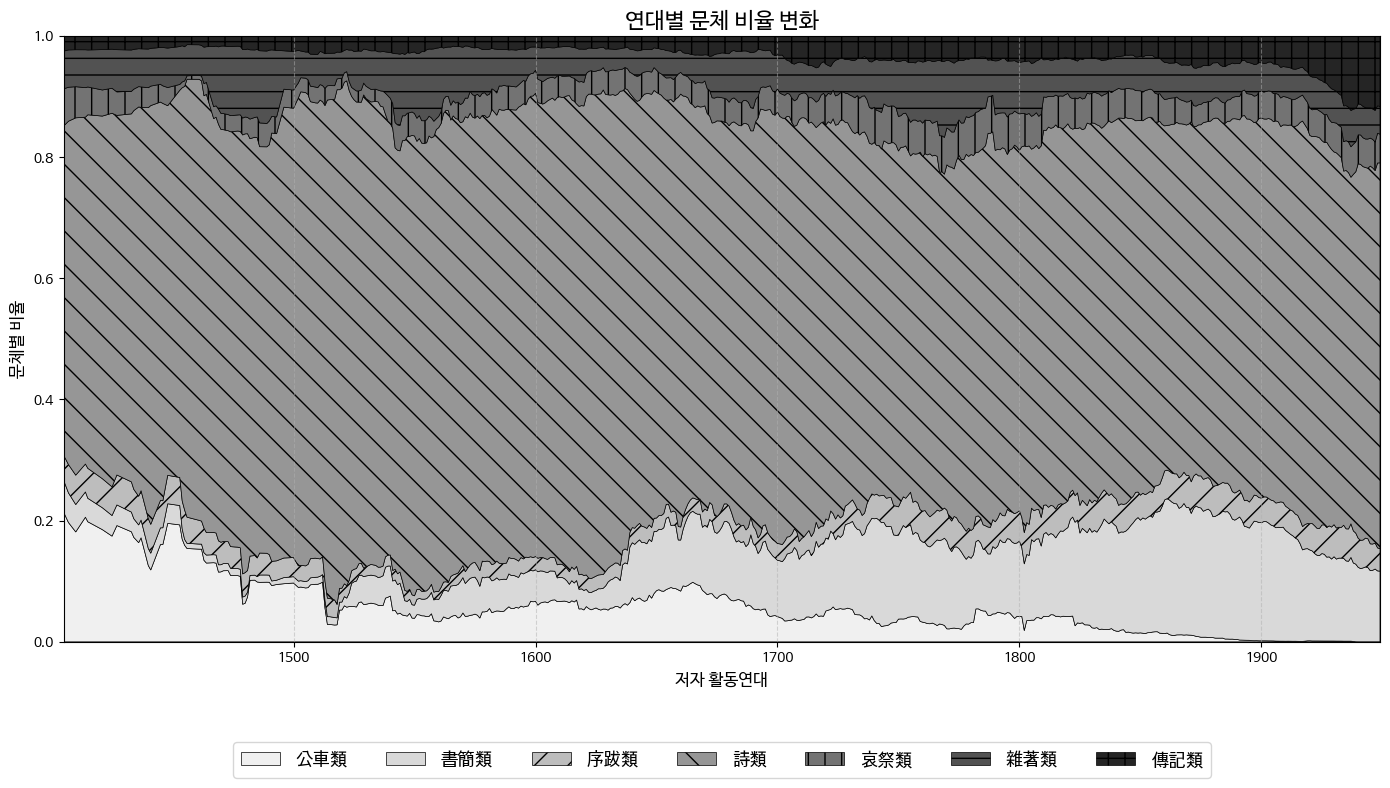

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv('Dataset_Munzip_Genre.csv')

# 활동 연대 계산 (생년과 몰년의 평균)
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2
df_clean['Activity_Year'] = df_clean['Activity_Year'].astype(int)

# 분석할 문체 컬럼 선정 (산문류 제외)
style_cols = ['公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類']

# 연대별 문체 양 합산
df_grouped = df_clean.groupby('Activity_Year')[style_cols].sum().sort_index()

# 비율(%)로 변환
# 각 행(연도)의 합계로 각 열(문체)을 나눔
df_ratios = df_grouped.div(df_grouped.sum(axis=1), axis=0).fillna(0)

# 그래프를 부드럽게 만들기 (Smoothing) - 20년 이동 평균 사용
# 너무 들쑥날쑥하면 보기 힘들어서 추세를 보여주기 위함입니다.
df_ratios_smooth = df_ratios.rolling(window=20, min_periods=1, center=True).mean()
# 스무딩 후 비율 합이 1이 되도록 다시 조정
df_ratios_smooth = df_ratios_smooth.div(df_ratios_smooth.sum(axis=1), axis=0)

# 3. 흑백 인쇄용 그래프 그리기
plt.figure(figsize=(14, 8))

# 흑백 식별을 위한 회색조 색상과 패턴 정의
greys = ['#f0f0f0', '#d9d9d9', '#bdbdbd', '#969696', '#737373', '#525252', '#252525']
patterns = ['', '', '/', '\\', '|', '-', '+'] # 빗금, 점 등 패턴

# 누적 영역 그래프 그리기
x = df_ratios_smooth.index
y = [df_ratios_smooth[col] for col in style_cols]

stacks = plt.stackplot(x, y, labels=style_cols, colors=greys, edgecolor='black', linewidth=0.5)

# 각 영역에 패턴 입히기 (인쇄 시 구분 명확화)
for stack, pattern in zip(stacks, patterns):
    stack.set_hatch(pattern)

# 축 및 범례 설정
plt.title('연대별 문체 비율 변화', fontsize=16)
plt.xlabel('저자 활동연대', fontsize=12)
plt.ylabel('문체별 비율', fontsize=12)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=14, ncol=7)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.margins(0, 0) # 양옆 여백 제거

plt.tight_layout()
plt.show()


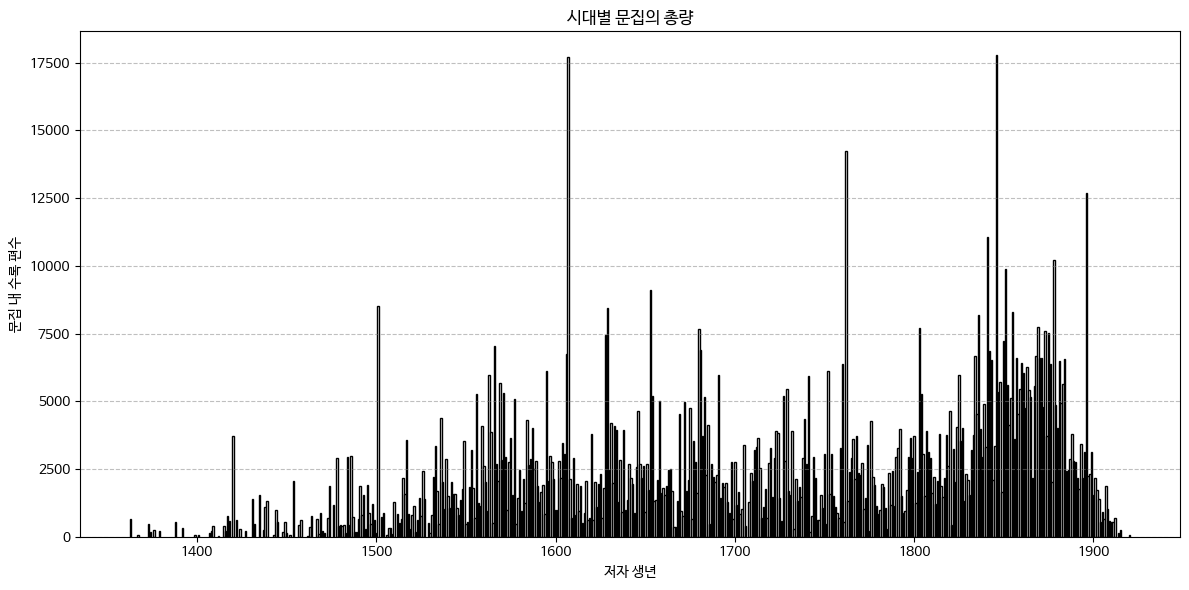

In [2]:

df = pd.read_csv('Dataset_Munzip_Genre.csv')

# 데이터 가공: '생년'을 기준으로 문집 총량('SUM') 합산
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
df_clean = df.dropna(subset=['생년'])
df_grouped = df_clean.groupby('생년')['SUM'].sum()

# 그래프 그리기
plt.figure(figsize=(12, 6))
plt.bar(df_grouped.index, df_grouped.values,
        color='white',      # 막대 내부: 흰색
        edgecolor='black',  # 테두리: 검정색
        linewidth=1.0)      # 선 두께

# 축 및 라벨 설정
plt.title('시대별 문집의 총량')
plt.xlabel('저자 생년')
plt.ylabel('문집 내 수록 편수')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray') # 보조선은 옅은 회색

# 그래프 저장 및 출력
plt.tight_layout()
plt.savefig('munjib_by_birthyear_bw.png')
plt.show()

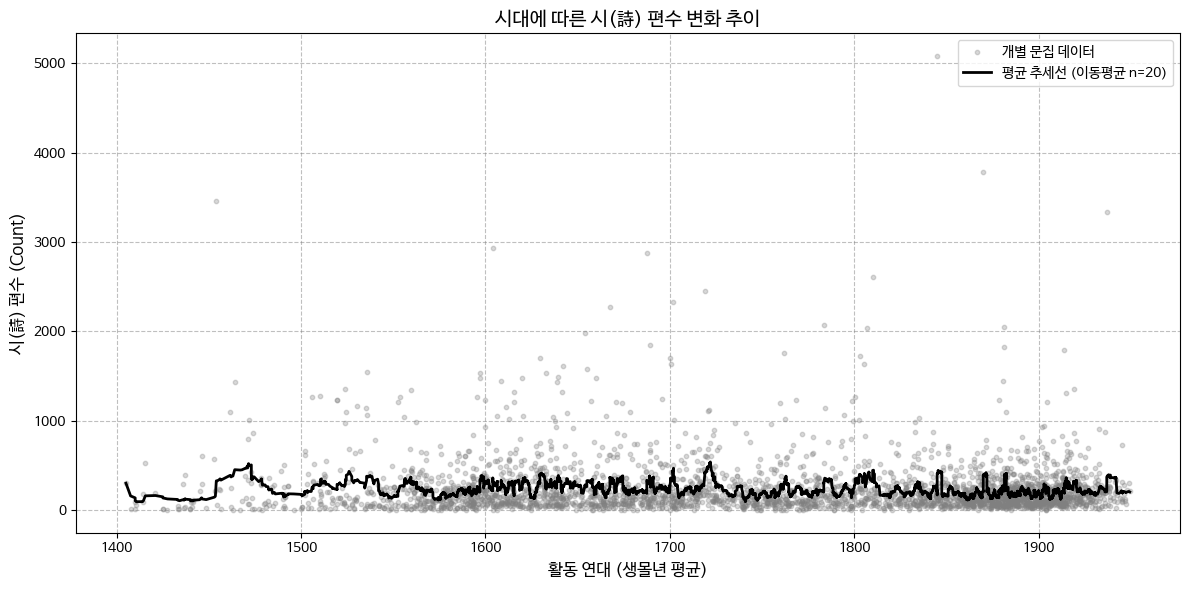

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('Dataset_Munzip_Genre.csv')

# 2. 데이터 전처리
# 연도와 편수 데이터를 숫자로 변환 (오류 방지)
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
df['몰년'] = pd.to_numeric(df['몰년'], errors='coerce')
df['詩類'] = pd.to_numeric(df['詩類'], errors='coerce')

# 결측치 제거
df_clean = df.dropna(subset=['생년', '몰년', '詩類'])

# 활동 연대 계산 (생년 + 몰년의 평균) 및 정렬
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2
df_sorted = df_clean.sort_values('Activity_Year')

# 이동평균선 구하기 (Trend Line)
# 20명 단위 평균
# window 값을 조절하면 선이 더 부드러워지거나(크게) 더 뾰족해집니다(작게).
window_size = 20
df_sorted['Rolling_Poetry_Count'] = df_sorted['詩類'].rolling(window=window_size, min_periods=1).mean()

# 4. 그래프 그리기 (흑백 인쇄 최적화)
plt.figure(figsize=(12, 6))

# (선택사항) 배경에 개별 데이터를 회색 점으로 표시하여 분포 보여주기
plt.scatter(df_sorted['Activity_Year'], df_sorted['詩類'],
            color='gray',
            s=10,        # 점 크기
            alpha=0.3,   # 투명도 (겹치는 부분 확인용)
            label='개별 문집 데이터')

# 메인: 추세선 그리기 (검정 실선)
plt.plot(df_sorted['Activity_Year'], df_sorted['Rolling_Poetry_Count'],
         color='black',       # 검정색
         linewidth=2,         # 굵기
         linestyle='-',       # 실선
         label=f'평균 추세선 (이동평균 n={window_size})')

# 축 및 레이블 설정
plt.title('시대에 따른 시(詩) 편수 변화 추이', fontsize=14)
plt.xlabel('활동 연대 (생몰년 평균)', fontsize=12)
plt.ylabel('시(詩) 편수 (Count)', fontsize=12)

# 범례 및 그리드
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5, color='gray')

# 저장 및 출력
plt.tight_layout()
plt.savefig('poetry_count_trend_line_bw.png')
plt.show()

/tmp/ipython-input-2970368549.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


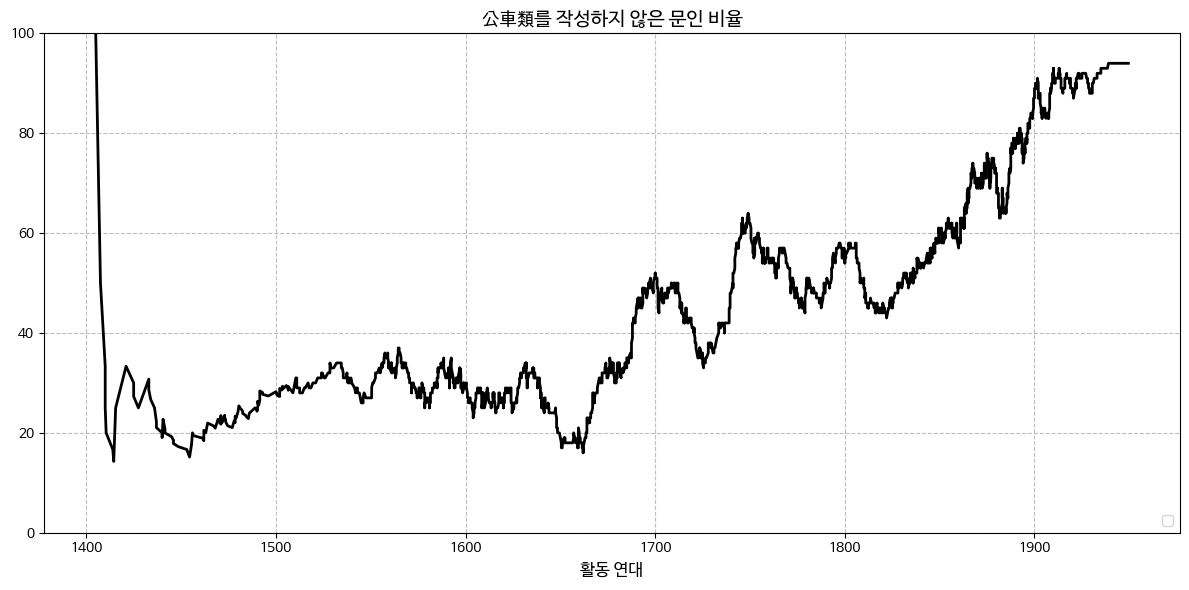

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
df['몰년'] = pd.to_numeric(df['몰년'], errors='coerce')
df['公車類'] = pd.to_numeric(df['公車類'], errors='coerce')

# 유효 데이터 필터링
df_clean = df.dropna(subset=['생년', '몰년', '公車類'])

# 활동 연대 계산
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2

# 공거류가 0이면 1(True), 0보다 크면 0(False)으로 변환
df_clean['No_Gonggeo'] = (df_clean['公車類'] == 0).astype(int)

# 연대순 정렬
df_sorted = df_clean.sort_values('Activity_Year')

# 이동평균을 통한 비율 산출
# 활동연대가 유사한 주변 100명의 문인 중 공거류를 안 쓴 사람이 몇 %인지 계산
window_size = 100
df_sorted['Rolling_Ratio'] = df_sorted['No_Gonggeo'].rolling(window=window_size, min_periods=1).mean() * 100

# 4. 그래프 그리기 (흑백 인쇄용)
plt.figure(figsize=(12, 6))
plt.plot(df_sorted['Activity_Year'], df_sorted['Rolling_Ratio'],
         color='black',       # 검정 실선
         linewidth=2)

# 축 및 레이블 설정
plt.title('公車類를 작성하지 않은 문인 비율', fontsize=14)
plt.xlabel('활동 연대', fontsize=12)
plt.ylim(0, 100) # 0% ~ 100% 범위 고정

# 그리드 및 범례
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('no_gonggeo_ratio_trend_bw.png')
plt.show()

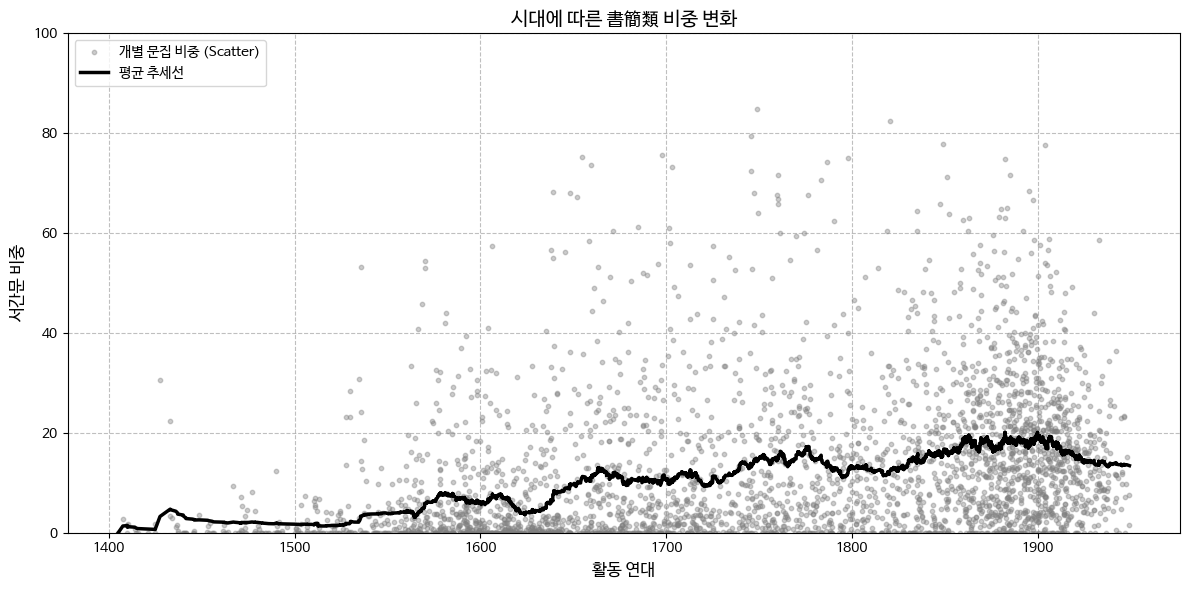

In [5]:
# 데이터 전처리
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
df['몰년'] = pd.to_numeric(df['몰년'], errors='coerce')
df['書簡類'] = pd.to_numeric(df['書簡類'], errors='coerce')
df['SUM'] = pd.to_numeric(df['SUM'], errors='coerce')

# 유효 데이터 필터링
df_clean = df.dropna(subset=['생년', '몰년', '書簡類', 'SUM'])

# 비중(%) 계산: 서간류 / 전체문집양 * 100
df_clean['Seogan_Ratio'] = (df_clean['書簡類'] / df_clean['SUM']) * 100

# 활동 연대 계산 및 정렬
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2
df_sorted = df_clean.sort_values('Activity_Year')

# 추세선 계산 (이동평균)
# 100명 단위의 평균을 내어 전체적인 흐름을 파악
window_size = 100
df_sorted['Rolling_Seogan_Ratio'] = df_sorted['Seogan_Ratio'].rolling(window=window_size, min_periods=1).mean()

# 4. 그래프 그리기
plt.figure(figsize=(12, 6))

# (1) 개별 데이터 산점도 (Scatter) - 비중
plt.scatter(df_sorted['Activity_Year'], df_sorted['Seogan_Ratio'],
            color='gray',
            s=10,
            alpha=0.4,
            label='개별 문집 비중 (Scatter)')

# (2) 추세선 (Trend Line) - 검정 실선
plt.plot(df_sorted['Activity_Year'], df_sorted['Rolling_Seogan_Ratio'],
         color='black',
         linewidth=2.5,
         linestyle='-',
         label=f'평균 추세선')

# 축 및 레이블 설정
plt.title('시대에 따른 書簡類 비중 변화', fontsize=14)
plt.xlabel('활동 연대', fontsize=12)
plt.ylabel('서간문 비중', fontsize=12)
plt.ylim(0, 100) # 0% ~ 100% 범위

# 그리드 및 범례
plt.grid(True, linestyle='--', alpha=0.5, color='gray')
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('seogan_ratio_trend_bw.png')
plt.show()

In [ ]:

# 데이터 전처리 및 계산
# 숫자형 변환 (오류 방지)
cols = ['생년', '몰년', '書簡類', 'SUM']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 유효 데이터만 필터링
df_clean = df.dropna(subset=cols)

# 활동 연대 계산 (생년+몰년 / 2)
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2

# 서간류 비중 계산 (%)
df_clean['Seogan_Ratio'] = (df_clean['書簡類'] / df_clean['SUM']) * 100

# 3. 시기별 데이터 추출
# 19세기 후반 (1850 <= 활동연대 < 1900)
period1 = df_clean[(df_clean['Activity_Year'] >= 1850) & (df_clean['Activity_Year'] < 1900)]

# 20세기 초반 (1900 <= 활동연대 < 1950)
period2 = df_clean[(df_clean['Activity_Year'] >= 1900) & (df_clean['Activity_Year'] < 1950)]

# 4. 상위 10명 출력
print("=== 19세기 후반 (1850-1900) 서간류 비중 Top 10 ===")
print(period1.sort_values(by='Seogan_Ratio', ascending=False)[['제목', '생년', 'Activity_Year', 'Seogan_Ratio']].head(10))

print("\n=== 20세기 초반 (1900-1950) 서간류 비중 Top 10 ===")
print(period2.sort_values(by='Seogan_Ratio', ascending=False)[['제목', '생년', 'Activity_Year', 'Seogan_Ratio']].head(10))

=== 19세기 후반 (1850-1900) 서간류 비중 Top 10 ===
          제목    생년  Activity_Year  Seogan_Ratio
2503  普山先生遺稿  1858         1882.5     74.825175
2564   老柏齋遺稿  1858         1885.0     71.698113
2119     仁山集  1814         1851.5     71.208226
2732    魯菴遺稿  1860         1895.5     68.333333
2768    養窩遺稿  1867         1897.5     66.666667
2506    持菴遺稿  1841         1883.5     65.095541
2470    鈍菴遺稿  1863         1880.5     64.880952
2136   ??齋文集  1826         1852.5     63.725490
2453    東亭遺稿  1851         1879.5     63.313609
2228     西山集  1827         1863.0     63.120567

=== 20세기 초반 (1900-1950) 서간류 비중 Top 10 ===
         제목    생년  Activity_Year  Seogan_Ratio
2885   芝山遺稿  1863         1904.0     77.647059
2924   竹師遺稿  1871         1906.0     58.904110
3239   直峰遺稿  1920         1933.0     58.571429
2831  篤守齋遺稿  1864         1901.5     57.627119
2919    春潭集  1889         1905.5     56.521739
2902   謙窩遺藁  1881         1904.0     54.000000
2916   重軒文集  1878         1905.0     53.634085
2985   石泉續稿

In [ ]:


# 데이터 전처리 및 계산
# 숫자형 변환 (오류 방지)
cols = ['생년', '몰년', '雜著類', 'SUM']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 유효 데이터만 필터링
df_clean = df.dropna(subset=cols)

# 활동 연대 계산 (생년+몰년 / 2)
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2

# 서간류 비중 계산 (%)
df_clean['Seogan_Ratio'] = (df_clean['雜著類'] / df_clean['SUM']) * 100

# 3. 시기별 데이터 추출
# 18세기 초반 (1700 <= 활동연대 < 1750)
period1 = df_clean[(df_clean['Activity_Year'] >= 1700) & (df_clean['Activity_Year'] < 1750)]

# 18세기 후반 (1750 <= 활동연대 < 1800)
period2 = df_clean[(df_clean['Activity_Year'] >= 1750) & (df_clean['Activity_Year'] < 1800)]

# 4. 상위 10명 출력
print("=== 18세기 초반 (1850-1900) 잡저류 비중 Top 10 ===")
print(period1.sort_values(by='Seogan_Ratio', ascending=False)[['제목', '생년', 'Activity_Year', 'Seogan_Ratio']].head(10))

print("\n=== 18세기 후반 (1900-1950) 잡저류 비중 Top 10 ===")
print(period2.sort_values(by='Seogan_Ratio', ascending=False)[['제목', '생년', 'Activity_Year', 'Seogan_Ratio']].head(10))

=== 18세기 초반 (1850-1900) 잡저류 비중 Top 10 ===
           제목    생년  Activity_Year  Seogan_Ratio
1395      白水集  1700         1733.5     51.116951
1434  鳳谷桂察訪遺集  1708         1741.5     50.292398
1208   釣巖先生文集  1672         1702.0     43.333333
1244      虛齋集  1674         1707.0     36.470588
1459    ____集  1708         1745.0     36.257310
1439     戒懼菴集  1702         1742.0     33.333333
1257      屛谷集  1672         1710.5     33.078394
1262     拙隱遺稿  1675         1711.5     31.333333
1298      東谿集  1693         1715.0     30.116959
1468     旅菴遺稿  1712         1746.5     29.361702

=== 18세기 후반 (1900-1950) 잡저류 비중 Top 10 ===
         제목    생년  Activity_Year  Seogan_Ratio
1786  與猶堂全書  1762         1799.0     78.345679
1538  允摯堂遺稿  1721         1757.0     69.230769
1578    耳溪集  1724         1763.0     65.247732
1661   弘齋全書  1752         1776.0     60.970258
1784  硏經齋全集  1760         1799.5     56.883671
1546    湛軒書  1731         1757.0     52.036199
1737  容忍齋遺稿  1759         1789.0     52.000000


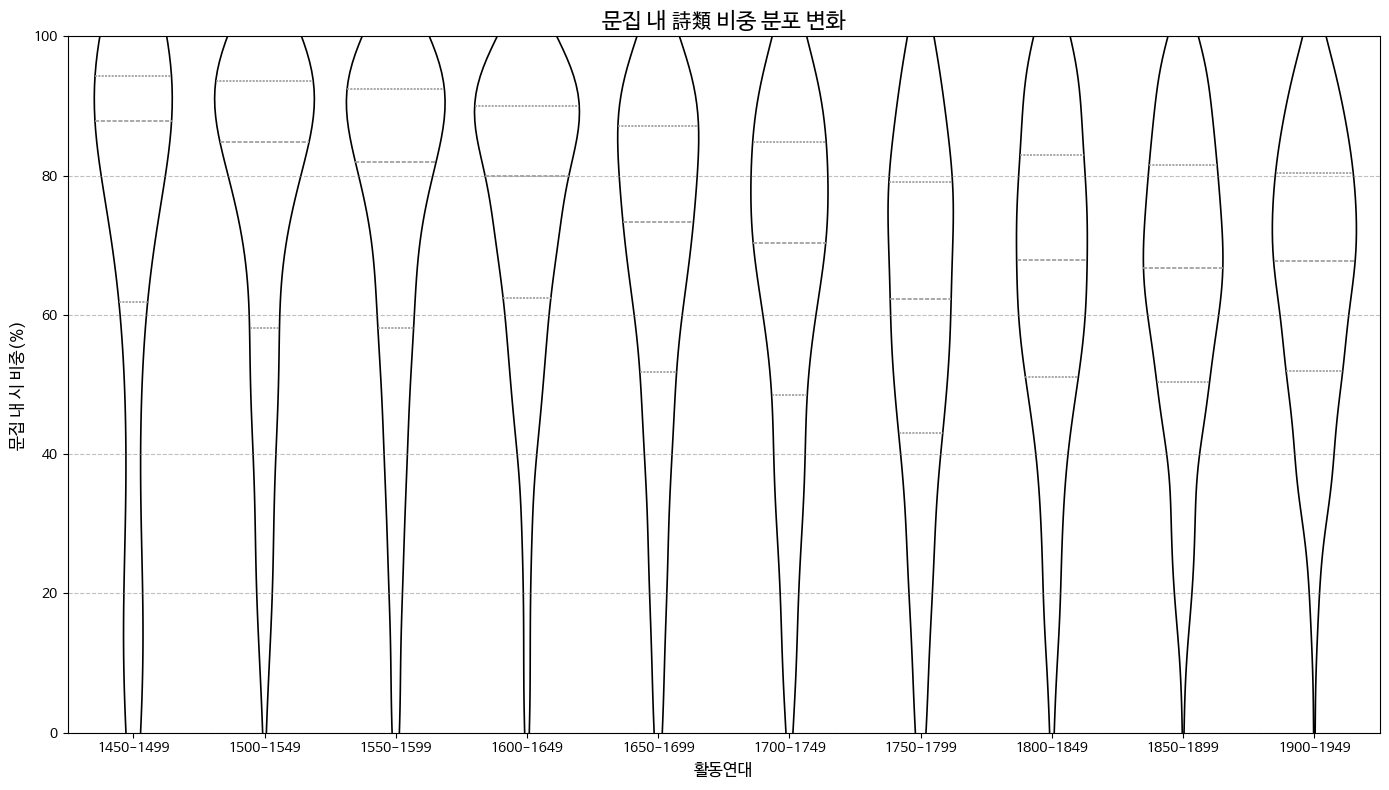

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 데이터 불러오기 및 전처리
df = pd.read_csv('Dataset_Munzip_Genre.csv')
df['생년'] = pd.to_numeric(df['생년'], errors='coerce')
df['몰년'] = pd.to_numeric(df['몰년'], errors='coerce')
df['詩類'] = pd.to_numeric(df['詩類'], errors='coerce')
df['SUM'] = pd.to_numeric(df['SUM'], errors='coerce')

df_clean = df.dropna(subset=['생년', '몰년', '詩類', 'SUM'])
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2
df_clean['Poetry_Ratio'] = (df_clean['詩類'] / df_clean['SUM']) * 100

# 2. 50년 단위 구간 나누기 (Binning)
bins = np.arange(1450, 1951, 50)
labels = [f"{i}-{i+49}" for i in bins[:-1]]
df_clean['Period'] = pd.cut(df_clean['Activity_Year'], bins=bins, labels=labels)
df_violin = df_clean.dropna(subset=['Period'])

# 3. Violin Plot 그리기
plt.figure(figsize=(14, 8))
sns.violinplot(x='Period', y='Poetry_Ratio', data=df_violin,
               color='white', inner='quartile', linewidth=1.2)

# 흑백 인쇄용 테두리 설정 (검정색)
for collection in plt.gca().collections:
    collection.set_edgecolor('black')
    collection.set_facecolor('white')

plt.title('문집 내 詩類 비중 분포 변화', fontsize=16)
plt.xlabel('활동연대', fontsize=12)
plt.ylabel('문집 내 시 비중(%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('poetry_ratio_violin_bw.png')
plt.show()

/tmp/ipython-input-505026442.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[pub_col] = df_clean[pub_col].astype(int)


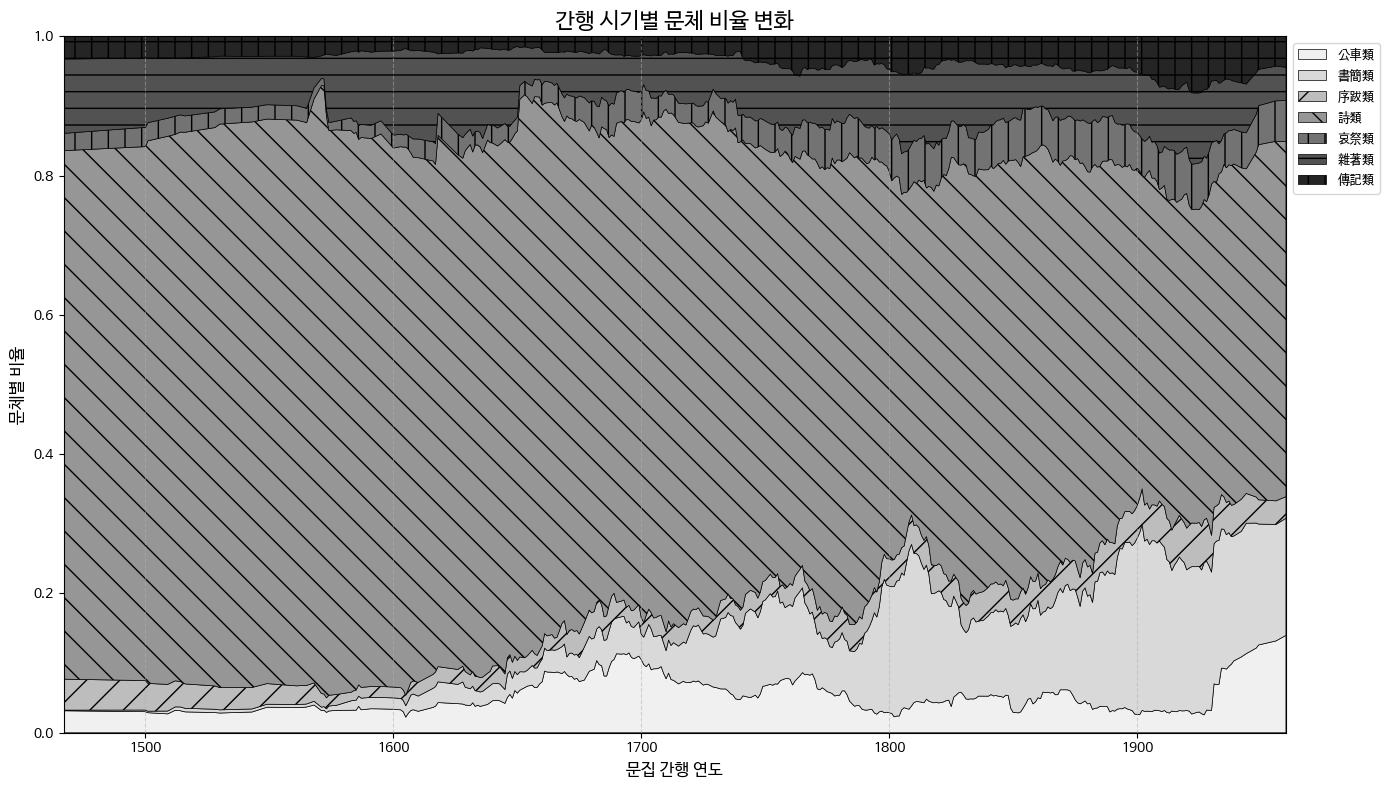

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('Dataset_Munzip_Genre.csv')
pub_col = 'Publish'

# 2. 데이터 전처리
# 간행년도 데이터 숫자 변환 (오류 데이터는 NaN 처리)
df[pub_col] = pd.to_numeric(df[pub_col], errors='coerce')

# 간행년도가 없는 데이터 제거
df_clean = df.dropna(subset=[pub_col])

# 연도 정수형 변환 및 정렬
df_clean[pub_col] = df_clean[pub_col].astype(int)
df_clean = df_clean.sort_values(pub_col)

# (선택사항) 너무 동떨어진 연도(예: 오기입으로 인한 0년, 2090년 등)를 제외하고 싶다면 아래 주석을 해제하세요.
# df_clean = df_clean[(df_clean[pub_col] >= 1400) & (df_clean[pub_col] <= 2000)]

# 분석할 문체 컬럼 선정
style_cols = ['公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類']

# 연대별 문체 양 합산 (기준이 'Activity_Year'에서 'pub_col'로 변경됨)
df_grouped = df_clean.groupby(pub_col)[style_cols].sum().sort_index()

# 비율(%)로 변환
# 각 행(연도)의 합계로 각 열(문체)을 나눔
df_ratios = df_grouped.div(df_grouped.sum(axis=1), axis=0).fillna(0)

# 그래프를 부드럽게 만들기 (Smoothing) - 20년 이동 평균 사용
# 간행년도는 특정 해에 몰릴 수 있으므로, 이동 평균이 추세를 보기에 더 좋습니다.
df_ratios_smooth = df_ratios.rolling(window=20, min_periods=1, center=True).mean()

# 스무딩 후 비율 합이 1이 되도록 다시 조정
df_ratios_smooth = df_ratios_smooth.div(df_ratios_smooth.sum(axis=1), axis=0)

# 3. 흑백 인쇄용 그래프 그리기
plt.figure(figsize=(14, 8))

# 흑백 식별을 위한 회색조 색상과 패턴 정의
greys = ['#f0f0f0', '#d9d9d9', '#bdbdbd', '#969696', '#737373', '#525252', '#252525']
patterns = ['', '', '/', '\\', '|', '-', '+'] # 빗금, 점 등 패턴

# 누적 영역 그래프 그리기
x = df_ratios_smooth.index
y = [df_ratios_smooth[col] for col in style_cols]

stacks = plt.stackplot(x, y, labels=style_cols, colors=greys, edgecolor='black', linewidth=0.5)

# 각 영역에 패턴 입히기 (인쇄 시 구분 명확화)
for stack, pattern in zip(stacks, patterns):
    stack.set_hatch(pattern)

# 축 및 범례 설정
plt.title('간행 시기별 문체 비율 변화', fontsize=16) # 제목 변경
plt.xlabel('문집 간행 연도', fontsize=12)          # X축 라벨 변경
plt.ylabel('문체별 비율', fontsize=12)

# 범례를 그래프 밖으로 뺌
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.margins(0, 0) # 양옆 여백 제거

plt.tight_layout()
plt.show()

▶ 적용된 보정 시차(Time Lag): 94년


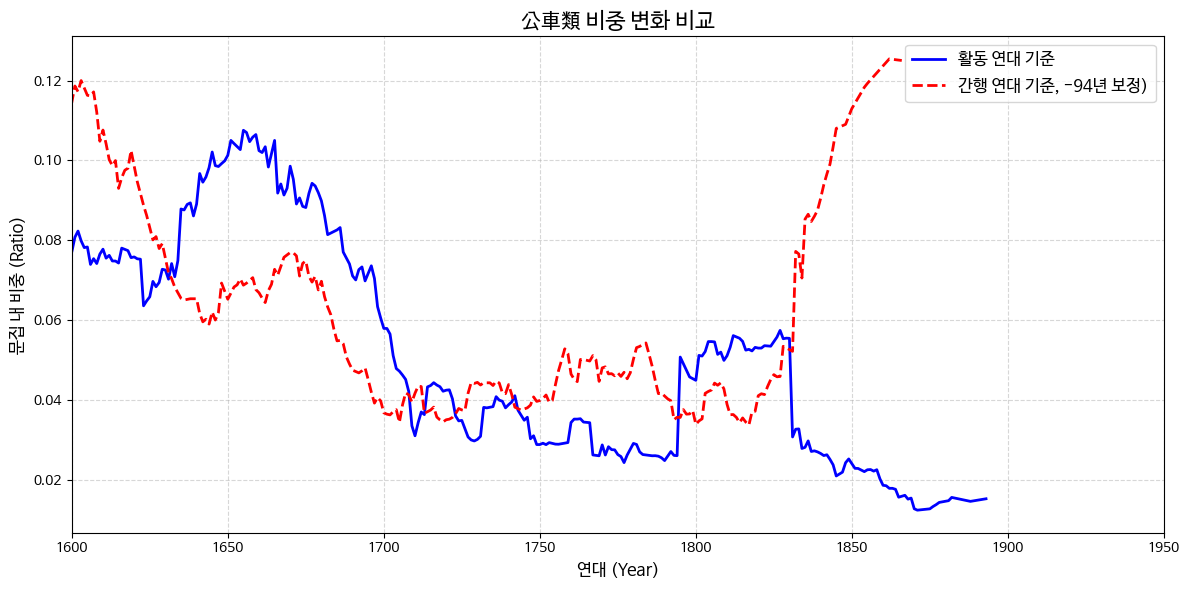

In [ ]:
df = pd.read_csv('Dataset_Munzip_Genre.csv')

# 숫자 변환
cols = ['생년', '몰년', '公車類', 'SUM', '간행년'] # 필요한 컬럼만 변환
pub_col = 'Publish'

for col in cols + [pub_col]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 유효 데이터 필터링
df_clean = df.dropna(subset=['생년', '몰년', 'SUM', pub_col])

# 활동 연대 및 비율 계산
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2
df_clean['Gonggeo_Ratio'] = df_clean['公車類'] / df_clean['SUM']

# 시차 계산 (간행년 - 활동년)
df_clean['Time_Lag'] = df_clean[pub_col] - df_clean['Activity_Year']
median_lag = df_clean['Time_Lag'].median() # 중앙값 계산 (약 94년)
shift_amount = int(median_lag)
print(f"▶ 적용된 보정 시차(Time Lag): {shift_amount}년")

# (1) 활동 연대 기준 트렌드
act_trend = df_clean.groupby(df_clean['Activity_Year'].astype(int))['Gonggeo_Ratio'].mean()
act_smooth = act_trend.rolling(window=30, min_periods=5, center=True).mean()

# (2) 간행 연대 기준 트렌드
pub_trend = df_clean.groupby(df_clean[pub_col].astype(int))['Gonggeo_Ratio'].mean()
pub_smooth = pub_trend.rolling(window=30, min_periods=5, center=True).mean()

# (3) 간행 연대 데이터 이동 (Shift)
# 간행 연도 트렌드의 시간축(index)을 보정값만큼 앞으로 당김
pub_smooth_shifted = pub_smooth.copy()
pub_smooth_shifted.index = pub_smooth_shifted.index - shift_amount


# 그래프 그리기 (공거류 비교)

plt.figure(figsize=(12, 6))

# 활동 연대 그래프 (파란 실선)
plt.plot(act_smooth.index, act_smooth,
         label='활동 연대 기준',
         color='blue', linewidth=2)

# 시차 보정된 간행 연대 그래프 (빨간 점선)
plt.plot(pub_smooth_shifted.index, pub_smooth_shifted,
         label=f'간행 연대 기준, -{shift_amount}년 보정)',
         color='red', linestyle='--', linewidth=2)

# 디자인 설정
plt.title(f'公車類 비중 변화 비교', fontsize=16)
plt.xlabel('연대 (Year)', fontsize=12)
plt.ylabel('문집 내 비중 (Ratio)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# X축 범위 설정 (데이터가 많은 1600~1950년 집중 조명)
plt.xlim(1600, 1950)

plt.tight_layout()
plt.show()

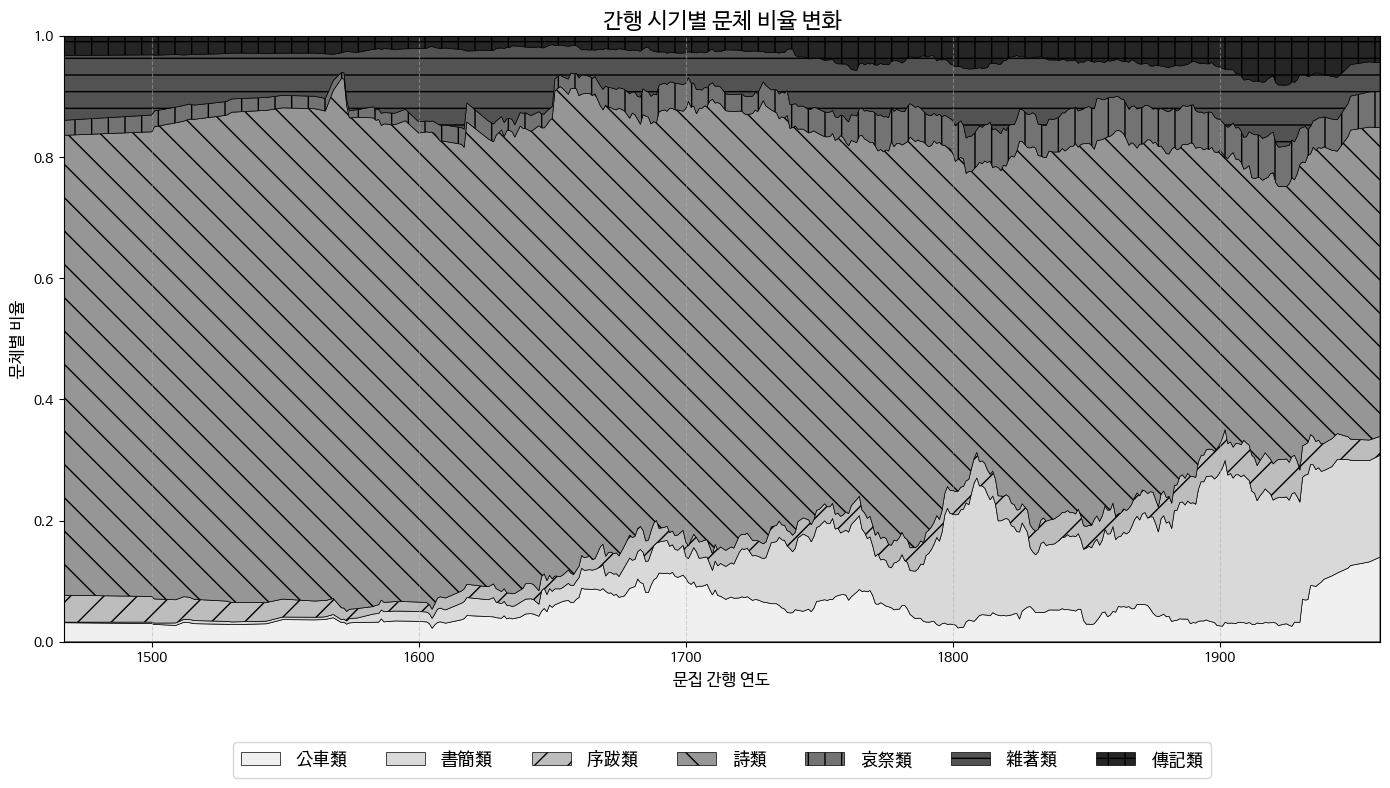

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 전처리
# 간행년도 데이터 숫자 변환 (오류 데이터는 NaN 처리)
df[pub_col] = pd.to_numeric(df[pub_col], errors='coerce')

# 간행년도가 없는 데이터 제거
df_clean = df.dropna(subset=[pub_col])

# 연도 정수형 변환 및 정렬
df_clean[pub_col] = df_clean[pub_col].astype(int)
df_clean = df_clean.sort_values(pub_col)

# (선택사항) 너무 동떨어진 연도(예: 오기입으로 인한 0년, 2090년 등)를 제외하고 싶다면 아래 주석을 해제하세요.
# df_clean = df_clean[(df_clean[pub_col] >= 1400) & (df_clean[pub_col] <= 2000)]

# 분석할 문체 컬럼 선정
style_cols = ['公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類']

# 연대별 문체 양 합산 (기준이 'Activity_Year'에서 'pub_col'로 변경됨)
df_grouped = df_clean.groupby(pub_col)[style_cols].sum().sort_index()

# 비율(%)로 변환
# 각 행(연도)의 합계로 각 열(문체)을 나눔
df_ratios = df_grouped.div(df_grouped.sum(axis=1), axis=0).fillna(0)

# 그래프를 부드럽게 만들기 (Smoothing) - 20년 이동 평균 사용
# 간행년도는 특정 해에 몰릴 수 있으므로, 이동 평균이 추세를 보기에 더 좋습니다.
df_ratios_smooth = df_ratios.rolling(window=20, min_periods=1, center=True).mean()

# 스무딩 후 비율 합이 1이 되도록 다시 조정
df_ratios_smooth = df_ratios_smooth.div(df_ratios_smooth.sum(axis=1), axis=0)

# 3. 흑백 인쇄용 그래프 그리기
plt.figure(figsize=(14, 8))

# 흑백 식별을 위한 회색조 색상과 패턴 정의
greys = ['#f0f0f0', '#d9d9d9', '#bdbdbd', '#969696', '#737373', '#525252', '#252525']
patterns = ['', '', '/', '\\', '|', '-', '+'] # 빗금, 점 등 패턴

# 누적 영역 그래프 그리기
x = df_ratios_smooth.index
y = [df_ratios_smooth[col] for col in style_cols]

stacks = plt.stackplot(x, y, labels=style_cols, colors=greys, edgecolor='black', linewidth=0.5)

# 각 영역에 패턴 입히기 (인쇄 시 구분 명확화)
for stack, pattern in zip(stacks, patterns):
    stack.set_hatch(pattern)

# 축 및 범례 설정
plt.title('간행 시기별 문체 비율 변화', fontsize=16) # 제목 변경
plt.xlabel('문집 간행 연도', fontsize=12)          # X축 라벨 변경
plt.ylabel('문체별 비율', fontsize=12)

# 범례를 그래프 밖으로 뺌
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fontsize=14, ncol=7)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.margins(0, 0) # 양옆 여백 제거

plt.tight_layout()
plt.show()

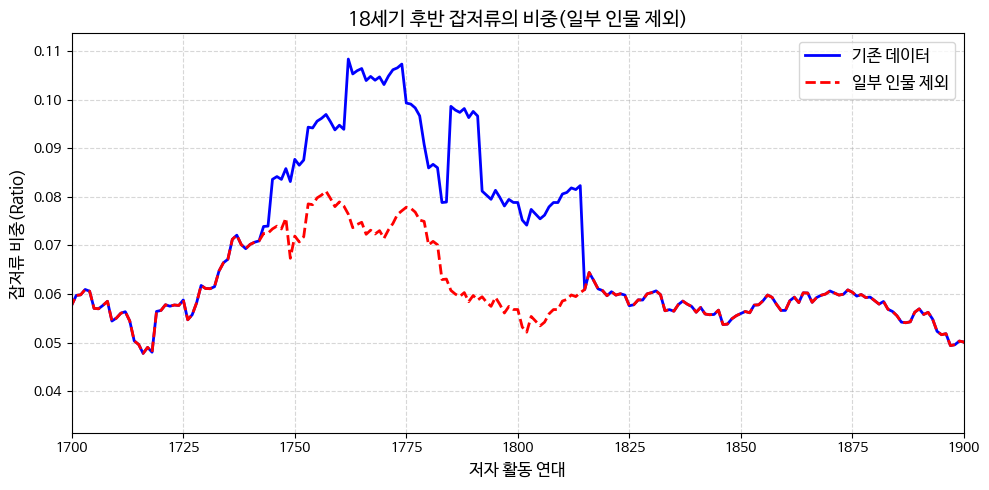

In [ ]:
# 데이터 불러오기 및 정제
for col in ['생년', '몰년', '雜著類', 'SUM']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df_clean = df.dropna(subset=['생년', '몰년', '雜著類', 'SUM'])
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2

# 3. 특정 인물 7인 필터링(문체명 직접 입력하여 수정)
keywords = ['與猶堂', '耳溪', '弘齋', '硏經齋', '湛軒', '樊巖', '泠齋']
mask = df_clean['제목'].str.contains('|'.join(keywords), na=False)

# 제외 전(Original)과 제외 후(Excluded) 데이터 분리
df_excluded = df_clean[~mask]

# 전체 분량 대비 비중 계산 함수 (이동평균)
def get_volume_trend(df_input):
    df_grouped = df_input.groupby(df_input['Activity_Year'].astype(int))[['雜著類', 'SUM']].sum()
    ratio = df_grouped['雜著類'] / df_grouped['SUM']
    return ratio.rolling(window=30, min_periods=5, center=True).mean()

vol_original = get_volume_trend(df_clean)
vol_excluded = get_volume_trend(df_excluded)

# 그래프 시각화
plt.figure(figsize=(10, 5))
plt.plot(vol_original.index, vol_original, label='기존 데이터', color='blue', linewidth=2)
plt.plot(vol_excluded.index, vol_excluded, label='일부 인물 제외', color='red', linestyle='--', linewidth=2)

# 디자인 설정
plt.title('18세기 후반 잡저류의 비중(일부 인물 제외)', fontsize=14)
plt.xlabel('저자 활동 연대', fontsize=12)
plt.ylabel('잡저류 비중(Ratio)', fontsize=12)
plt.xlim(1700, 1900)

plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

In [9]:
# 시차에 따른 상관관계 계산

import pandas as pd
import scipy.stats as stats

pub_col = 'Publish'

cols = ['생년', '몰년', '公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類', 'SUM', pub_col]
for col in cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df.dropna(subset=['생년', '몰년', 'SUM', pub_col]).copy()
df_clean['Activity_Year'] = (df_clean['생년'] + df_clean['몰년']) / 2

# 문체별 비중 계산
styles = ['公車類', '書簡類', '序跋類', '詩類', '哀祭類', '雜著類', '傳記類']
for style in styles:
    df_clean[f'{style}_Ratio'] = df_clean[style] / df_clean['SUM']

# 시차(Time Lag) 계산 및 보정
df_clean['Time_Lag'] = df_clean[pub_col] - df_clean['Activity_Year']
shift_amount = int(df_clean['Time_Lag'].median()) # 중간값으로 시차 계산

# 활동연대 기준 이동평균 (Window=30)
act_trend = df_clean.groupby(df_clean['Activity_Year'].astype(int))[[f'{s}_Ratio' for s in styles]].mean()
act_smooth = act_trend.rolling(window=30, min_periods=5, center=True).mean()

# 간행연도 기준 이동평균 및 시차(Shift) 적용
pub_trend = df_clean.groupby(df_clean[pub_col].astype(int))[[f'{s}_Ratio' for s in styles]].mean()
pub_smooth = pub_trend.rolling(window=30, min_periods=5, center=True).mean()
pub_smooth_shifted = pub_smooth.copy()
pub_smooth_shifted.index = pub_smooth_shifted.index - shift_amount

# 각 문체별 상관관계 및 P-value 출력
print(f"적용된 시차(Time Lag) 보정값: {shift_amount}년")
print(f"{'문체':<10} | {'Pearson r':<10} | {'P-value':<10} | {'유의성 판정'}")
print("-" * 55)

for style in styles:
    col_name = f'{style}_Ratio'
    aligned = pd.concat([act_smooth[col_name], pub_smooth_shifted[col_name]], axis=1, keys=['Act', 'Pub_Shifted']).dropna()

    if not aligned.empty:
        r, p = stats.pearsonr(aligned['Act'], aligned['Pub_Shifted'])
        significance = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "NS"
        print(f"{style:<10} | {r:.4f}     | {p:.2e}   | {significance}")

적용된 시차(Time Lag) 보정값: 94년
문체         | Pearson r  | P-value    | 유의성 판정
-------------------------------------------------------
公車類        | 0.3872     | 9.73e-12   | ***
書簡類        | 0.8815     | 3.53e-95   | ***
序跋類        | 0.5751     | 9.29e-27   | ***
詩類         | 0.7426     | 1.02e-51   | ***
哀祭類        | 0.7209     | 1.86e-47   | ***
雜著類        | -0.0518     | 3.81e-01   | NS
傳記類        | 0.7056     | 1.07e-44   | ***
